# Neural network for image classification - cats and dogs


## Approach 1 - extract all the pixels


### Importing the libraries


In [1]:
import os
import zipfile

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from google.colab.patches import cv2_imshow

### Extracting pixels from images


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
path = '/content/drive/MyDrive/Computer-Vision/Datasets/cat_dog_1.zip'
zip_object = zipfile.ZipFile(file=path, mode='r')
zip_object.extractall('./')
zip_object.close()

In [4]:
directory_train = '/content/cat_dog_1/train'
directory_test = '/content/cat_dog_1/test'
files_train = [os.path.join(directory_train, f)
               for f in sorted(os.listdir(directory_train))]
files_test = [os.path.join(directory_test, f)
              for f in sorted(os.listdir(directory_test))]

In [5]:
height, width = 128, 128

In [6]:
len(files_train)

4000

#### Train


In [7]:
images = []
classes = []
for image_path in files_train:
    try:
        image = cv2.imread(image_path)
        (H, W) = image.shape[:2]
    except:
        continue

    image = cv2.resize(image, (width, height))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image = image.ravel()
    images.append(image)

    image_name = os.path.basename(os.path.normpath(image_path))
    if image_name.startswith('c'):
        # Cat
        class_name = 0
    else:
        # Dog
        class_name = 1

    classes.append(class_name)

In [8]:
X_train = np.asarray(images)
y_train = np.asarray(classes)

In [9]:
X_train.shape

(4000, 16384)

In [10]:
y_train.shape

(4000,)

#### Test


In [11]:
images = []
classes = []
for image_path in files_test:
    try:
        image = cv2.imread(image_path)
        (H, W) = image.shape[:2]
    except:
        continue

    image = cv2.resize(image, (width, height))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    image = image.ravel()
    images.append(image)

    image_name = os.path.basename(os.path.normpath(image_path))
    if image_name.startswith('c'):
        # Cat
        class_name = 0
    else:
        # Dog
        class_name = 1

    classes.append(class_name)

In [12]:
X_test = np.asarray(images)
y_test = np.asarray(classes)

In [13]:
X_test.shape, y_test.shape

((1000, 16384), (1000,))

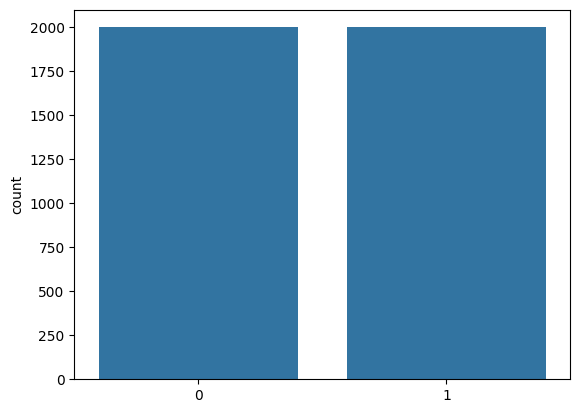

In [14]:
sns.countplot(x=y_train)

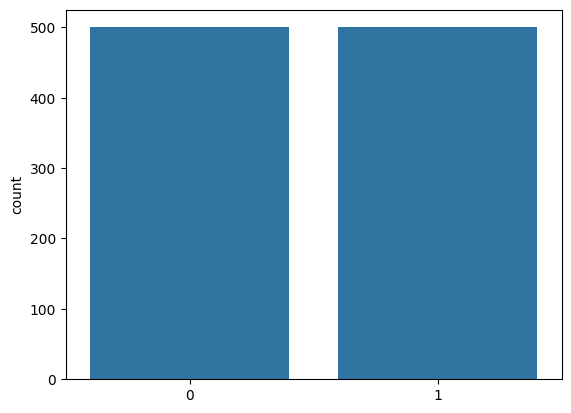

In [15]:
sns.countplot(x=y_test)

### Normalizing the data


In [16]:
X_train[0].max(), X_train[0].min()

(np.uint8(236), np.uint8(1))

In [17]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
X_train[0].max(), X_train[0].min()

(np.float64(0.9254901960784314), np.float64(0.0))

In [19]:
X_test[0].max(), X_test[0].min()

(np.float64(1.0), np.float64(-0.003937007874015748))

### Building and training the neural network


In [20]:
(16384 + 2) / 2

8193.0

In [21]:
from keras.layers import Dense, Input
from keras.models import Sequential

# 16384 -> 8193 -> 8193 -> 1
network1 = Sequential()
network1.add(Input(shape=(16384,)))
network1.add(Dense(units=8193, activation='relu'))
network1.add(Dense(units=8193, activation='relu'))
network1.add(Dense(units=1, activation='sigmoid'))

In [22]:
network1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8193)           │   134,242,305 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8193)           │    67,133,442 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         8,194 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 201,383,941 (768.22 MB)

 Trainable params: 201,383,941 (768.22 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
from keras.losses import BinaryCrossentropy
from keras.optimizers import Adam

# https://keras.io/api/optimizers/
# https://keras.io/api/losses/
network1.compile(
    optimizer=Adam(),
    loss=BinaryCrossentropy(),
    metrics=['accuracy']
)

In [24]:
history = network1.fit(X_train, y_train, epochs=50)

Epoch 1/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.5041 - loss: 24.9844
Epoch 2/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5299 - loss: 0.7214
Epoch 3/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5355 - loss: 0.6981
Epoch 4/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5649 - loss: 0.6807
Epoch 5/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5669 - loss: 0.6869
Epoch 6/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5586 - loss: 0.6806
Epoch 7/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5497 - loss: 0.6767
Epoch 8/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5922 - loss: 0.6692
Epoch 9/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5850 - loss: 0.6717
Epoch 10/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5814 - loss: 0.6657
Epoch 11/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5965 - loss: 0.6667
Epoch 12/50
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/ste

### Evaluating the neural network


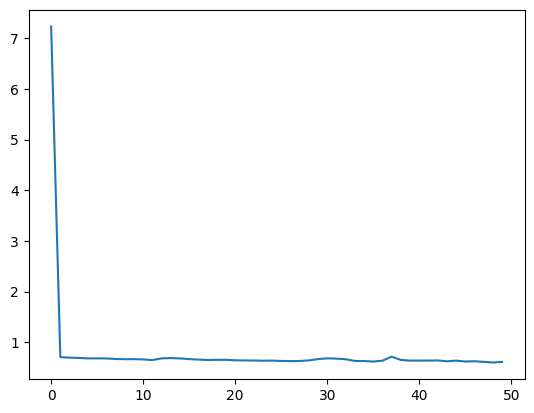

In [25]:
plt.plot(history.history['loss'])

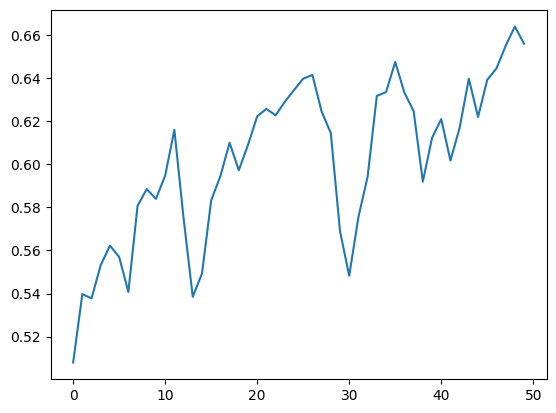

In [26]:
plt.plot(history.history['accuracy'])

In [27]:
X_test.shape

(1000, 16384)

In [28]:
predictions = network1.predict(X_test)
predictions

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step


array([[3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [4.7333074e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [6.4928168e-01],
       [3.1099969e-01],
       [2.2041798e-04],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [4.9460712e-01],
       [3.1099969e-01],
       [3.1523368e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [4.6771729e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [4.5253775e-01],
       [3.1099969e-01],
       [5.0051790e-01],
       [2.3447506e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [8.8600554e-02],
       [3.1099969e-01],
       [3.7476355e-01],
       [3.1099969e-01],
       [3.1143725e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.1099969e-01],
       [3.109996

In [29]:
# 0 False - Bart
# 1 True  - Homer

In [30]:
predictions = (predictions > 0.5)
predictions

array([[False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [False],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [False],
       [ True],
       [False],
       [False],
       [ True],
       [

In [31]:
y_test

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [32]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, predictions)

0.55

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, predictions)
cm

array([[419,  81],
       [369, 131]])

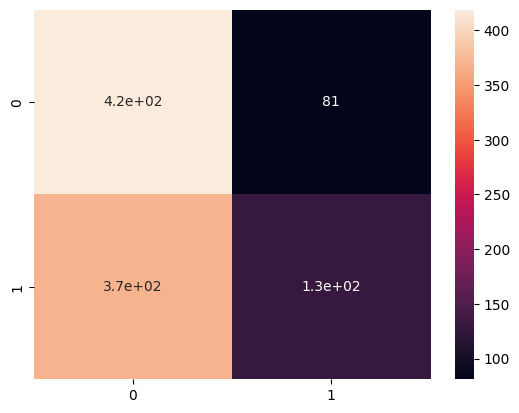

In [34]:
sns.heatmap(cm, annot=True)

In [35]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.53      0.84      0.65       500
           1       0.62      0.26      0.37       500

    accuracy                           0.55      1000
   macro avg       0.57      0.55      0.51      1000
weighted avg       0.57      0.55      0.51      1000

